In [2]:
# -*- coding: utf-8 -*-
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np

### 引入数据 ###
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# 训练集，测试集拆分
X_train, X_test, y_train, y_test = train_test_split(
    data, target, test_size=0.25, random_state=42
)

# 数据标准化处理
# 特征值标准化
std_x = StandardScaler()
X_train = std_x.fit_transform(X_train)
X_test = std_x.transform(X_test)

# 目标值标准化
std_y = StandardScaler()
y_train = std_y.fit_transform(y_train.reshape(-1, 1))
y_test = std_y.transform(y_test.reshape(-1, 1))

# 正规方程 线性回归预测
lr = LinearRegression()
lr.fit(X_train, y_train)
print("正规方程系数：", lr.coef_)

y_lr_predict = std_y.inverse_transform(lr.predict(X_test))
print("正规方程预测结果：", y_lr_predict)

# 梯度下降 线性回归预测
sgd = SGDRegressor()
sgd.fit(X_train, y_train.ravel())
print("梯度下降系数：", sgd.coef_)

y_sgd_predict = std_y.inverse_transform(sgd.predict(X_test).reshape(-1, 1))
print("梯度下降预测结果：", y_sgd_predict)

# 性能评估 均方误差
lr_mse = mean_squared_error(std_y.inverse_transform(y_test), y_lr_predict)
sgd_mse = mean_squared_error(std_y.inverse_transform(y_test), y_sgd_predict)

print("正规方程均方误差：", lr_mse)
print("梯度下降均方误差：", sgd_mse)

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/var/folders/gj/1vjc3x7550v04d2k7nrxcfl80000gn/T/ipykernel_94950/641486320.py:11: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


正规方程系数： [[-0.11314142  0.07237366  0.03602897  0.07828984 -0.20513545  0.3336194
  -0.02717002 -0.31385575  0.23512134 -0.17534836 -0.22163401  0.12236864
  -0.39237591]]
正规方程预测结果： [[28.83885359]
 [36.00783288]
 [15.08324755]
 [25.23090886]
 [18.87864064]
 [23.21398327]
 [17.5931124 ]
 [14.30508093]
 [23.05438985]
 [20.62008346]
 [24.78514683]
 [18.66833668]
 [-6.9788951 ]
 [21.83575737]
 [19.20898992]
 [26.2868054 ]
 [20.54379176]
 [ 5.65713224]
 [40.42358065]
 [17.64146116]
 [27.32258958]
 [30.05056174]
 [11.15013704]
 [24.11530393]
 [17.89145648]
 [15.79348591]
 [22.94743453]
 [14.2586068 ]
 [22.26731194]
 [19.24709013]
 [22.26897546]
 [25.24344002]
 [25.69165643]
 [17.98759507]
 [16.70286649]
 [17.11631225]
 [31.19643534]
 [20.17835831]
 [23.71828436]
 [24.79196868]
 [13.94575895]
 [32.00389982]
 [42.53869791]
 [17.44523722]
 [27.15354457]
 [17.07482215]
 [13.89272021]
 [26.06440323]
 [20.36888769]
 [29.97813037]
 [21.35346608]
 [34.32287916]
 [15.88498671]
 [26.17757739]
 [39.5097

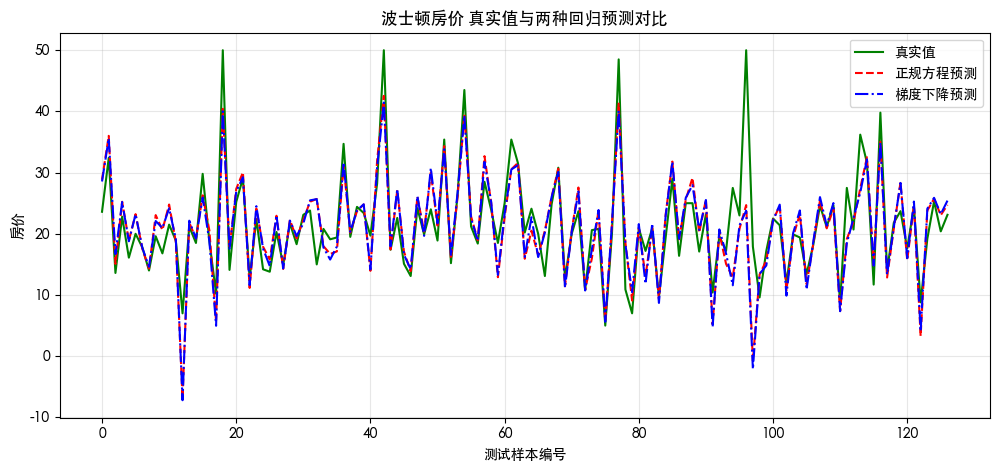

In [5]:
import matplotlib.pyplot as plt
# 解决中文和负号显示
plt.rcParams['font.sans-serif'] = ['Heiti TC']  # 设置中文字体为黑体
plt.rcParams['axes.unicode_minus'] = False

# 取出真实值、两个模型预测值
y_true = std_y.inverse_transform(y_test).flatten()
y_lr_pred = y_lr_predict.flatten()
y_sgd_pred = y_sgd_predict.flatten()

# 绘图
plt.figure(figsize=(12, 5))
x = range(len(y_true))
plt.plot(x, y_true, label='真实值', color='green')
plt.plot(x, y_lr_pred, label='正规方程预测', color='red', linestyle='--')
plt.plot(x, y_sgd_pred, label='梯度下降预测', color='blue', linestyle='-.')

plt.title('波士顿房价 真实值与两种回归预测对比')
plt.xlabel('测试样本编号')
plt.ylabel('房价')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()